In [141]:
import numpy as np
np.set_printoptions(edgeitems=30, linewidth=200) # 적당히 보기 편한 값으로 수정 필요.
from modules.utils import generate_orthonormal_states

import matplotlib
import matplotlib.pyplot as plt
matplotlib.use('Agg')  # For saving figures

dim = 16
number_of_basis = 3
basis_states = generate_orthonormal_states(dim, number_of_basis)
print("Orthogonal states shape:", basis_states.shape)  # (number_of_basis, dim)
assert np.allclose(basis_states @ basis_states.T.conj(), np.eye(number_of_basis)), "state vectors are not orthogonal"

Orthogonal states shape: (3, 16)


In [115]:
from torch.autograd import Variable
import torch
import torch.nn as nn
import pennylane as qml

import importlib
from modules import QGAN, Discriminator, MINE  # 초기 import
importlib.reload(QGAN)  # 모듈 갱신
importlib.reload(Discriminator)  # 모듈 갱신
importlib.reload(MINE)  # 모듈 갱신

G_layers = 5
D_layers = 5
n_qubits = 4
code_qubits = number_of_basis
smooth = 0.0
BATCH_SIZE = 16

ml_device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
quantum_device = qml.device("default.qubit", wires=n_qubits)
print("고전 머신러닝 device =", ml_device, "양자 회로 backend =", quantum_device)

generator_initial_params = Variable(torch.tensor(np.random.normal(-np.pi/3, np.pi/3, (G_layers, n_qubits, 3))), requires_grad=True)
generator = QGAN.QGenerator(n_qubits, n_qubits, G_layers, generator_initial_params, quantum_device, give_me_states=True) # 상태를 얻어야 Discriminator에 넣음.

discriminator_initial_params = Variable(torch.tensor(np.random.normal(-np.pi/2 , np.pi/2, (D_layers, n_qubits, 3))), requires_grad=True)
discriminator = QGAN.QDiscriminator(n_qubits, D_layers, discriminator_initial_params, quantum_device)

mine = MINE.LinearMine(code_dim=code_qubits, output_dim=2**n_qubits, size=100)

고전 머신러닝 device = cpu 양자 회로 backend = <default.qubit device (wires=4) at 0x1f068b660b0>


In [116]:
a = discriminator.forward(torch.tensor(basis_states[:number_of_basis]))
print(a, a.dtype)

tensor([0.3091, 0.4142, 0.4452], dtype=torch.float64, grad_fn=<StackBackward0>) torch.float64


In [117]:
def combine_quantum_states(states, train_size, combine_mode):
    # combine given quantum states to generate combined quantum states
    assert combine_mode in ["linspace", "uniform"], "combine_mode should be 'linspace' or 'uniform'"
    num_of_states = len(states)
    dim_of_states = len(states[0])

    if combine_mode == "uniform":
        # use dirichlet distribution to generate random weights
        alpha = np.ones(num_of_states)
        matrix = np.random.dirichlet(alpha, size=train_size)
        coeff = np.sqrt(matrix)
        combined_states = np.dot(coeff, states)
        return combined_states
    
    elif combine_mode == "linspace":
        pass #TODO: linspace방법도 구현한 다음 비교하자. train_size조건이 좀 까다로울듯


In [104]:
train_size = 1000

train_dataset = combine_quantum_states(basis_states, train_size, "uniform")
train_tensor = torch.tensor(train_dataset, dtype=torch.float32)
assert np.allclose(np.linalg.norm(train_dataset, axis=1), np.ones(train_size)), "combined states are not normalized"

In [105]:
G_lr = 0.001
D_lr = 0.0001
M_lr = 0.001
G_opt = torch.optim.Adam([generator.params], lr=G_lr)
D_opt = torch.optim.Adam([discriminator.params], lr=D_lr)
M_opt = torch.optim.Adam(mine.parameters(), lr=M_lr)

In [106]:
def generator_train_step(generator_seed, coeff, use_mine = False):
    '''
    params (torch.Tensor(레이어,큐빗,3)): a parameter
    generator_input (torch.Tensor(BATCH_SIZE, seed_dim)): 생성기 입력 seed (code+noise).
    '''
    code_input = generator_seed[:, :code_qubits] # 입력중에서 code만 뽑는다. (BATCH_SIZE, code_qubits)
    generator_probs, generator_states = generator.forward(generator_seed) # 출력을 뽑아낸다 (BATCH_SIZE, 2**output_qubits) * 2
    generator_probs = generator_probs.to(torch.float32)
    generator_states = generator_states.to(torch.float32)
    
    disc_output = discriminator.forward(generator_states).to(torch.float32) # quantum discriminator
    gan_loss = torch.log(1-disc_output).mean()
    
    if use_mine:
        pred_xy = mine(code_input, generator_probs)
        code_input_shuffle = code_input[torch.randperm(BATCH_SIZE)]
        pred_x_y = mine(code_input_shuffle, generator_probs)
        mi = torch.mean(pred_xy) - torch.log(torch.mean(torch.exp(pred_x_y)))
        gan_loss -= coeff * mi

    return generator_states, gan_loss

disc_loss_fn = nn.BCELoss()
def disc_cost_fn(real_input, fake_input):
    batch_num = real_input.shape[0]

    disc_real = discriminator.forward(real_input)
    disc_fake = discriminator.forward(fake_input)

    real_label = torch.ones((batch_num, 1)).to(ml_device)
    fake_label = torch.zeros((batch_num, 1)).to(ml_device)
    
    if smooth > 0.00001:
        real_label = real_label - smooth*torch.rand(real_label.shape).to(ml_device)
    
    loss = 0.5 * (disc_loss_fn(disc_real, real_label) + disc_loss_fn(disc_fake, fake_label))
    
    return loss

In [142]:
def visualize_output_simple(gen_states, gen_codes, epoch, writer, image_file_path):

    # 1. 첫 번째 플롯: 각 basis_states에 사영시켰을 때, 차지하는 평균 비중 시각화
    magnitudes = (np.abs(gen_states.detach().numpy().conjugate() @ basis_states.T)**2).mean(axis=0)

    plt.bar(range(number_of_basis), magnitudes)
    plt.title(f"epoch = {epoch}")
    plt.xlabel("Index")
    plt.ylabel("Projection Magnitude")
    # save plt
    writer.add_figure(f'Projection Magnitude', plt.gcf(), epoch)
    plt.savefig(f'{image_file_path}/projection_epoch{epoch:03d}.png')
    plt.close()

In [108]:
probs, states = generator.forward(torch.empty((BATCH_SIZE, n_qubits)).uniform_(-np.pi, np.pi))

In [137]:
(np.abs(states.detach().numpy().conjugate() @ basis_states.T)**2).mean(axis=0)

array([0.05595418, 0.06106412, 0.06256234])

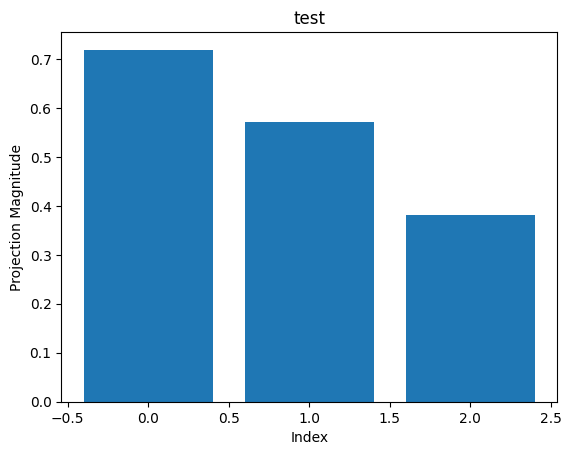

In [140]:
import numpy as np
import matplotlib.pyplot as plt

# 크기 n의 배열 (예제 데이터)
n = 3
data = np.random.rand(n)
plt.bar(range(n), data)
plt.title("test")
plt.xlabel("Index")
plt.ylabel("Projection Magnitude")
plt.show()


In [ ]:
basis_states